# Google Play Reviews EDA — All-in-One Notebook

This notebook is designed for a Google Play review CSV with the schema:

- `app_id`
- `review_id`
- `user_name`
- `score`
- `review_text`
- `thumbs_up`
- `review_created_at`
- `app_version`
- `reply_text`
- `reply_created_at`
- `lang`
- `country`

It covers:

1. **Key distributions** — ratings, review length, app distribution, review volume over time  
2. **Observable patterns** — review length by rating, reply rate by rating  
3. **Data quality issues** — duplicates, short/noisy reviews, Unicode/language flags, missing fields  
4. **Cleaning guidance** — creation of quality flags and cleaned text columns  
5. **Exports** — summary tables, plots, cleaned CSV, and a Markdown report

## 0) Install packages if needed
Run this once locally if your environment does not already have the packages.

In [ ]:
# !pip install pandas numpy matplotlib

## 1) Configuration
Change `INPUT_CSV` to your local file path.

In [ ]:
import google.colab
google.colab.drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/Sciencia AI')

Mounted at /content/drive


In [ ]:
from pathlib import Path

INPUT_CSV = "google_play_reviews_clean.csv"   # <-- change this
OUTPUT_DIR = Path("google_play_eda_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

APP_COL = "app_id"
REVIEW_ID_COL = "review_id"
USER_COL = "user_name"
RATING_COL = "score"
TEXT_COL = "review_text"
THUMBS_UP_COL = "thumbs_up"
DATE_COL = "review_created_at"
APP_VERSION_COL = "app_version"
REPLY_COL = "reply_text"
REPLY_DATE_COL = "reply_created_at"
LANG_COL = "lang"
COUNTRY_COL = "country"

## 2) Imports

In [ ]:
import re
import json
import math
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3) Load data and validate schema

In [ ]:
df = pd.read_csv(INPUT_CSV)

required_cols = [
    APP_COL, REVIEW_ID_COL, RATING_COL, TEXT_COL, THUMBS_UP_COL,
    DATE_COL, APP_VERSION_COL, REPLY_COL, REPLY_DATE_COL, LANG_COL, COUNTRY_COL
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Shape:", df.shape)
display(df.head())
print("\nColumns:", list(df.columns))

Shape: (29999, 12)


,app_id,review_id,user_name,score,review_text,thumbs_up,review_created_at,app_version,reply_text,reply_created_at,lang,country
0,com.spotify.music,89de08ec-a11a-4ea9-80d1-c1c4d2d4fc82,Eliza,5,no ads and keep it that way,0,2026-04-06T01:43:24,9.1.34.2060,NaN,NaN,en,us
1,com.spotify.music,8d3a368e-7955-4534-84ab-796d71dad11d,Kayla Sprowls,5,the best for downloading and listening to music,0,2026-04-06T01:42:43,9.1.34.2060,NaN,NaN,en,us
2,com.spotify.music,c7c4b188-5468-4046-8e0e-eb8820fb5b2f,Jenny “JMac” Sedberry,5,Spotify is a great app for listening to music ...,0,2026-04-06T01:40:29,9.1.34.2060,NaN,NaN,en,us
3,com.spotify.music,5757d546-d991-41f7-8718-9194c305b622,R “Roger That” Smith,4,feelin satisfied..!!,0,2026-04-06T01:37:45,9.1.34.2060,NaN,NaN,en,us
4,com.spotify.music,63b899be-8a0f-42cc-ac96-d89e7e80eac5,Sappala Anil Kumar,5,best 👌,0,2026-04-06T01:22:19,9.1.28.2252,NaN,NaN,en,us



Columns: ['app_id', 'review_id', 'user_name', 'score', 'review_text', 'thumbs_up', 'review_created_at', 'app_version', 'reply_text', 'reply_created_at', 'lang', 'country']


## 4) Basic type cleanup
This step does **not** alter the original raw text column. It only prepares working copies.

In [ ]:
# Preserve raw text
df["raw_text"] = df[TEXT_COL].copy()

# Normalize obvious types
df[RATING_COL] = pd.to_numeric(df[RATING_COL], errors="coerce")
df[THUMBS_UP_COL] = pd.to_numeric(df[THUMBS_UP_COL], errors="coerce")
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df[REPLY_DATE_COL] = pd.to_datetime(df[REPLY_DATE_COL], errors="coerce")

# Safe text copies
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
df[REPLY_COL] = df[REPLY_COL].fillna("").astype(str)
df[APP_VERSION_COL] = df[APP_VERSION_COL].astype("string")
df[LANG_COL] = df[LANG_COL].astype("string")
df[COUNTRY_COL] = df[COUNTRY_COL].astype("string")

print(df.dtypes)

app_id                       object
review_id                    object
user_name                    object
score                         int64
review_text                  object
thumbs_up                     int64
review_created_at    datetime64[ns]
app_version          string[python]
reply_text                   object
reply_created_at     datetime64[ns]
lang                 string[python]
country              string[python]
raw_text                     object
dtype: object


## 5) Helper functions

In [ ]:
BOILERPLATE_PRAISE = {
    "good", "great", "nice", "awesome", "excellent", "love it", "amazing",
    "best", "cool", "super", "perfect", "very good", "good app", "great app",
    "nice app", "best app", "excellent app", "awesome app", "love this app"
}

def normalize_unicode(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    # remove zero-width and BOM-like characters
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)
    return text

def collapse_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

def normalize_repeated_punct(text: str) -> str:
    text = re.sub(r"([!?.,])\1{2,}", r"\1\1", text)
    return text

def clean_text_basic(text: str) -> str:
    text = normalize_unicode(text)
    text = normalize_repeated_punct(text)
    text = collapse_whitespace(text)
    return text

def word_count(text: str) -> int:
    text = str(text).strip()
    if not text:
        return 0
    return len(text.split())

def char_count(text: str) -> int:
    return len(str(text))

def is_punct_or_symbol_only(text: str) -> bool:
    text = str(text).strip()
    if not text:
        return False
    # remove whitespace
    compact = re.sub(r"\s+", "", text)
    if not compact:
        return False
    return all(unicodedata.category(ch)[0] in {"P", "S"} for ch in compact)

def has_repeated_char_noise(text: str) -> bool:
    text = str(text).strip().lower()
    return bool(re.search(r"(.)\1{4,}", text))

def is_all_caps(text: str) -> bool:
    text = str(text).strip()
    letters = re.sub(r"[^A-Za-z]", "", text)
    if len(letters) < 3:
        return False
    return letters.isupper()

def is_non_ascii(text: str) -> bool:
    return any(ord(ch) > 127 for ch in str(text))

def is_boilerplate_praise(text: str) -> bool:
    t = clean_text_basic(str(text)).lower()
    return t in BOILERPLATE_PRAISE

def top_share(series: pd.Series, n: int) -> float:
    counts = series.value_counts(dropna=False)
    if counts.sum() == 0:
        return np.nan
    return counts.head(n).sum() / counts.sum()

def pct(x):
    return round(float(x) * 100, 2)

def save_plot(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

## 6) Create analysis and quality columns

In [ ]:
df["clean_text"] = df[TEXT_COL].map(clean_text_basic)
df["clean_text_lower"] = df["clean_text"].str.lower()

df["word_count"] = df["clean_text"].map(word_count)
df["char_count"] = df["clean_text"].map(char_count)
df["has_reply"] = df[REPLY_COL].str.strip().ne("")

df["is_empty_text"] = df["clean_text"].eq("")
df["is_single_token"] = df["word_count"].eq(1)
df["is_two_words_or_less"] = df["word_count"].le(2)
df["is_very_short_chars_lt5"] = df["char_count"].lt(5)
df["is_punct_or_symbol_only"] = df["clean_text"].map(is_punct_or_symbol_only)
df["has_repeated_char_noise"] = df["clean_text"].map(has_repeated_char_noise)
df["is_all_caps"] = df["clean_text"].map(is_all_caps)
df["is_non_ascii"] = df["clean_text"].map(is_non_ascii)
df["is_boilerplate_praise"] = df["clean_text_lower"].map(is_boilerplate_praise)
df["invalid_rating_zero"] = df[RATING_COL].eq(0)

# duplicates
df["dup_review_id"] = df.duplicated(subset=[REVIEW_ID_COL], keep=False)
df["dup_text_global"] = df.duplicated(subset=["clean_text"], keep=False)
df["dup_text_within_app"] = df.duplicated(subset=[APP_COL, "clean_text"], keep=False)

# monthly period
df["review_month"] = df[DATE_COL].dt.to_period("M").astype("string")

display(df[[APP_COL, REVIEW_ID_COL, RATING_COL, TEXT_COL, "clean_text", "word_count", "char_count", "has_reply"]].head())

,app_id,review_id,score,review_text,clean_text,word_count,char_count,has_reply
0,com.spotify.music,89de08ec-a11a-4ea9-80d1-c1c4d2d4fc82,5,no ads and keep it that way,no ads and keep it that way,7,27,False
1,com.spotify.music,8d3a368e-7955-4534-84ab-796d71dad11d,5,the best for downloading and listening to music,the best for downloading and listening to music,8,47,False
2,com.spotify.music,c7c4b188-5468-4046-8e0e-eb8820fb5b2f,5,Spotify is a great app for listening to music ...,Spotify is a great app for listening to music ...,51,290,False
3,com.spotify.music,5757d546-d991-41f7-8718-9194c305b622,4,feelin satisfied..!!,feelin satisfied..!!,2,20,False
4,com.spotify.music,63b899be-8a0f-42cc-ac96-d89e7e80eac5,5,best 👌,best 👌,2,6,False


## 7) Basic dataset overview

In [ ]:
overview = {
    "rows": int(len(df)),
    "columns": 12,
    "unique_apps": int(df[APP_COL].nunique(dropna=True)),
    "unique_review_ids": int(df[REVIEW_ID_COL].nunique(dropna=True)),
    "min_date": None if df[DATE_COL].dropna().empty else str(df[DATE_COL].min()),
    "max_date": None if df[DATE_COL].dropna().empty else str(df[DATE_COL].max()),
    "top_3_app_share_pct": pct(top_share(df[APP_COL], 3)),
    "top_10_app_share_pct": pct(top_share(df[APP_COL], 10)),
    "lang_values": sorted([str(x) for x in df[LANG_COL].dropna().unique().tolist()])[:20],
    "country_values": sorted([str(x) for x in df[COUNTRY_COL].dropna().unique().tolist()])[:20],
}
overview

{'rows': 29999,
 'columns': 12,
 'unique_apps': 5,
 'unique_review_ids': 29999,
 'min_date': '2026-03-20 19:21:02',
 'max_date': '2026-04-06 02:08:43',
 'top_3_app_share_pct': 60.0,
 'top_10_app_share_pct': 100.0,
 'lang_values': ['en'],
 'country_values': ['us']}

## 8) Key distributions
### 8.1 Rating distribution

,score,count,pct
0,1,5920,0.1973
1,2,1256,0.0419
2,3,1470,0.0490
3,4,2362,0.0787
4,5,18991,0.6331


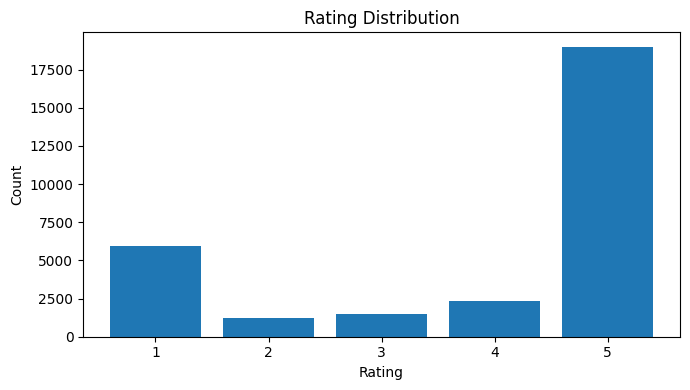

In [ ]:
rating_counts = df[RATING_COL].value_counts(dropna=False).sort_index()
rating_pct = (rating_counts / len(df)).round(4)

rating_dist = pd.DataFrame({
    "count": rating_counts,
    "pct": rating_pct
}).reset_index().rename(columns={"index": "rating"})

display(rating_dist)

plt.figure(figsize=(7,4))
plt.bar(rating_dist["score"].astype(str), rating_dist["count"])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
save_plot(OUTPUT_DIR / "rating_distribution.png")

### 8.2 Review length distributions

,count,mean,std,min,50%,90%,95%,99%,max
word_count,29999.0,10.697557,16.880410,1.0,4.0,29.0,48.0,86.02,138.0
char_count,29999.0,55.938531,91.296445,1.0,19.0,153.0,256.0,487.02,501.0


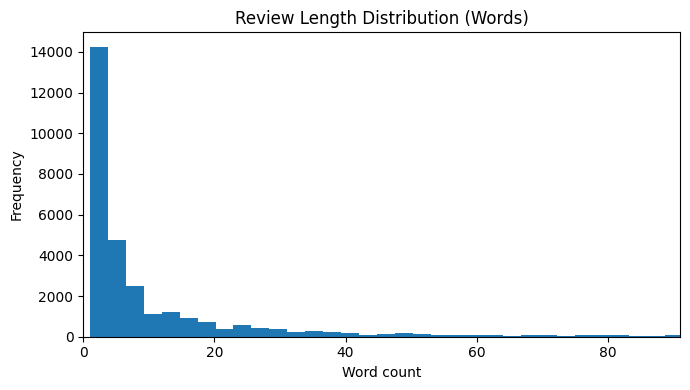

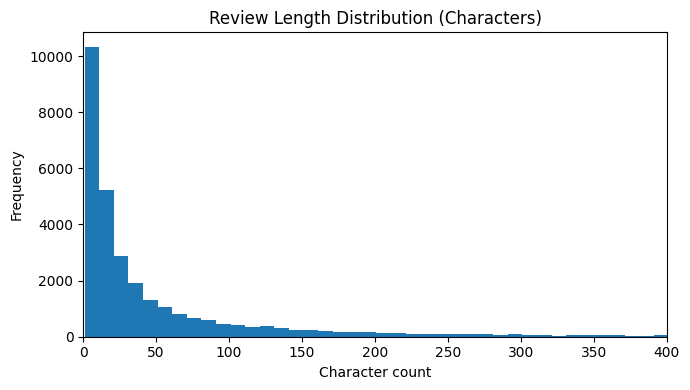

In [ ]:
length_summary = df[["word_count", "char_count"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
display(length_summary)

plt.figure(figsize=(7,4))
plt.hist(df["word_count"], bins=50)
plt.title("Review Length Distribution (Words)")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.xlim(0, min(100, int(df["word_count"].quantile(0.99)) + 5))
save_plot(OUTPUT_DIR / "review_length_words_hist.png")

plt.figure(figsize=(7,4))
plt.hist(df["char_count"], bins=50)
plt.title("Review Length Distribution (Characters)")
plt.xlabel("Character count")
plt.ylabel("Frequency")
plt.xlim(0, min(400, int(df["char_count"].quantile(0.99)) + 20))
save_plot(OUTPUT_DIR / "review_length_chars_hist.png")

### 8.3 App distribution

,app_id,review_count
0,com.spotify.music,6000
1,com.instagram.android,6000
2,com.zhiliaoapp.musically,6000
3,com.whatsapp,6000
4,com.snapchat.android,5999


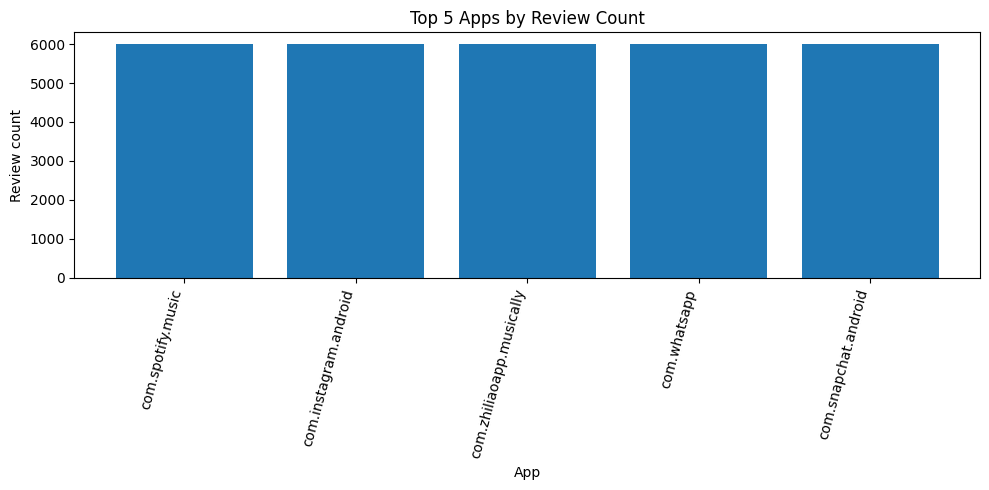

In [ ]:
app_counts = df[APP_COL].value_counts().reset_index()
app_counts.columns = [APP_COL, "review_count"]
display(app_counts.head(20))

top_n = min(15, len(app_counts))
plt.figure(figsize=(10,5))
plt.bar(app_counts.head(top_n)[APP_COL], app_counts.head(top_n)["review_count"])
plt.title(f"Top {top_n} Apps by Review Count")
plt.xlabel("App")
plt.ylabel("Review count")
plt.xticks(rotation=75, ha="right")
save_plot(OUTPUT_DIR / "top_apps.png")

### 8.4 Review volume over time

,review_month,review_count
0,2026-03,8760
1,2026-04,21239


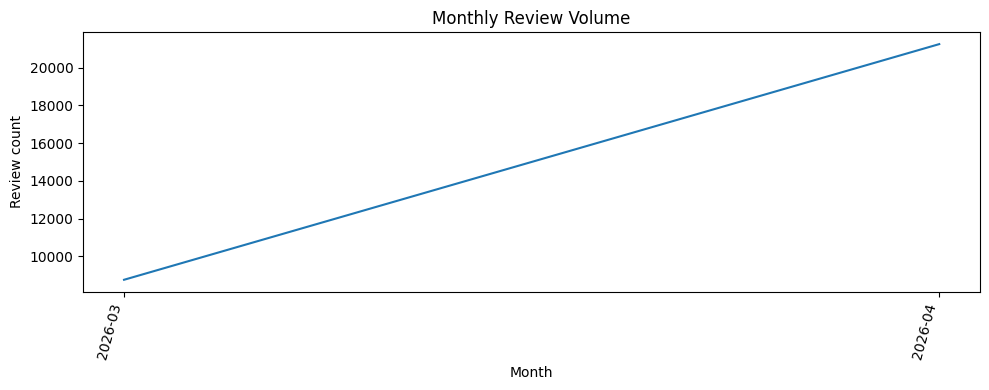

In [ ]:
monthly_counts = df.dropna(subset=[DATE_COL]).groupby("review_month").size().reset_index(name="review_count")
display(monthly_counts.tail(12))

if len(monthly_counts) > 0:
    plt.figure(figsize=(10,4))
    plt.plot(monthly_counts["review_month"], monthly_counts["review_count"])
    plt.title("Monthly Review Volume")
    plt.xlabel("Month")
    plt.ylabel("Review count")
    plt.xticks(rotation=75, ha="right")
    save_plot(OUTPUT_DIR / "monthly_review_volume.png")
else:
    print("No valid dates available for monthly volume chart.")

## 9) Observable patterns in the data
### 9.1 Median review length by rating

,score,word_count
0,1,12.0
1,2,14.0
2,3,8.0
3,4,4.0
4,5,3.0


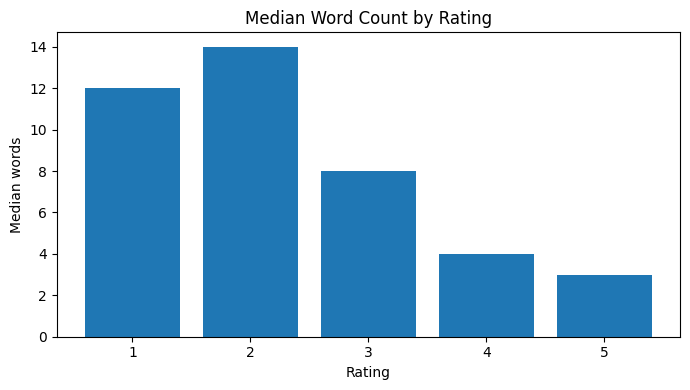

In [ ]:
median_words_by_rating = (
    df.groupby(RATING_COL)["word_count"]
      .median()
      .reset_index()
      .sort_values(RATING_COL)
)

display(median_words_by_rating)

plt.figure(figsize=(7,4))
plt.bar(median_words_by_rating[RATING_COL].astype(str), median_words_by_rating["word_count"])
plt.title("Median Word Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Median words")
save_plot(OUTPUT_DIR / "median_words_by_rating.png")

### 9.2 Developer reply rate by rating

,score,reply_rate_pct
0,1,22.92
1,2,27.07
2,3,22.18
3,4,16.93
4,5,16.71


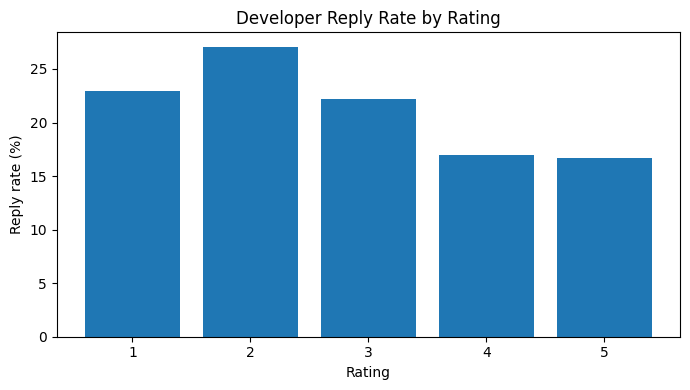

In [ ]:
reply_rate_by_rating = (
    df.groupby(RATING_COL)["has_reply"]
      .mean()
      .reset_index()
      .sort_values(RATING_COL)
)

reply_rate_by_rating["reply_rate_pct"] = (reply_rate_by_rating["has_reply"] * 100).round(2)
display(reply_rate_by_rating[[RATING_COL, "reply_rate_pct"]])

plt.figure(figsize=(7,4))
plt.bar(reply_rate_by_rating[RATING_COL].astype(str), reply_rate_by_rating["reply_rate_pct"])
plt.title("Developer Reply Rate by Rating")
plt.xlabel("Rating")
plt.ylabel("Reply rate (%)")
save_plot(OUTPUT_DIR / "reply_rate_by_rating.png")

### 9.3 Helpful votes vs rating

In [ ]:
thumbs_summary = (
    df.groupby(RATING_COL)[THUMBS_UP_COL]
      .agg(["count", "mean", "median", "max"])
      .reset_index()
      .sort_values(RATING_COL)
)
display(thumbs_summary)

,score,count,mean,median,max
0,1,5920,3.834628,0.0,3591
1,2,1256,1.324045,0.0,264
2,3,1470,3.264626,0.0,3898
3,4,2362,1.063082,0.0,1164
4,5,18991,0.358854,0.0,1759


## 10) Data quality issues

In [ ]:
quality = {
    "empty_text_pct": pct(df["is_empty_text"].mean()),
    "single_token_pct": pct(df["is_single_token"].mean()),
    "two_words_or_less_pct": pct(df["is_two_words_or_less"].mean()),
    "very_short_chars_lt5_pct": pct(df["is_very_short_chars_lt5"].mean()),
    "boilerplate_praise_pct": pct(df["is_boilerplate_praise"].mean()),
    "punct_or_symbol_only_pct": pct(df["is_punct_or_symbol_only"].mean()),
    "repeated_char_noise_pct": pct(df["has_repeated_char_noise"].mean()),
    "all_caps_pct": pct(df["is_all_caps"].mean()),
    "non_ascii_pct": pct(df["is_non_ascii"].mean()),
    "duplicate_review_id_pct": pct(df["dup_review_id"].mean()),
    "duplicate_text_global_pct": pct(df["dup_text_global"].mean()),
    "duplicate_text_within_app_pct": pct(df["dup_text_within_app"].mean()),
    "invalid_rating_zero_count": int(df["invalid_rating_zero"].sum()),
    "missing_reply_text_pct": pct(df[REPLY_COL].str.strip().eq("").mean()),
}
quality_df = pd.DataFrame(list(quality.items()), columns=["metric", "value"])
display(quality_df)

,metric,value
0,empty_text_pct,0.00
1,single_token_pct,22.46
2,two_words_or_less_pct,38.21
3,very_short_chars_lt5_pct,15.21
4,boilerplate_praise_pct,15.97
5,punct_or_symbol_only_pct,2.01
6,repeated_char_noise_pct,1.16
7,all_caps_pct,0.88
8,non_ascii_pct,19.80
9,duplicate_review_id_pct,0.00


### 10.1 Duplicate text inspection

In [ ]:
dup_examples = (
    df.loc[df["dup_text_within_app"], [APP_COL, "clean_text", REVIEW_ID_COL, RATING_COL]]
      .groupby([APP_COL, "clean_text"])
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

display(dup_examples.head(20))

,app_id,clean_text,count
682,com.whatsapp,good,569
294,com.snapchat.android,good,360
75,com.instagram.android,good,327
916,com.zhiliaoapp.musically,good,229
744,com.whatsapp,nice,192
122,com.instagram.android,nice,155
338,com.snapchat.android,nice,155
502,com.spotify.music,good,126
604,com.whatsapp,Good,126
843,com.zhiliaoapp.musically,Good,94


### 10.2 Short / noisy review examples

In [ ]:
examples_cols = [APP_COL, REVIEW_ID_COL, RATING_COL, TEXT_COL, "word_count", "char_count"]

print("Single-token examples:")
display(df.loc[df["is_single_token"], examples_cols].head(10))

print("Punctuation/symbol-only examples:")
display(df.loc[df["is_punct_or_symbol_only"], examples_cols].head(10))

print("Repeated-char-noise examples:")
display(df.loc[df["has_repeated_char_noise"], examples_cols].head(10))

Single-token examples:


,app_id,review_id,score,review_text,word_count,char_count
7,com.spotify.music,1faba35d-4d48-4ea8-b6fa-4df5f5d608f5,4,Great,1,5
10,com.spotify.music,d06e79a6-a430-4f11-a764-e7539ccf4940,5,best,1,4
12,com.spotify.music,05bb2386-86d5-4ac6-95d6-122af39aa905,1,hogshit,1,7
13,com.spotify.music,8e5e6a74-9019-45e1-96a1-4e17584e3600,5,Good,1,4
15,com.spotify.music,a81a063c-5c0f-4cd4-a2da-a5d50b0b3e3a,5,👍,1,1
46,com.spotify.music,feb08a2b-f087-459f-815d-aa4a40761590,1,Refund,1,6
48,com.spotify.music,bc4cc08f-3183-4b50-8f23-f18504409a57,5,Excelent,1,8
50,com.spotify.music,f4fece04-4828-40cd-8bd3-ee1e4c323810,5,sensational,1,11
61,com.spotify.music,dbdfd0ca-c2ce-4d23-b639-1b9e6c743102,5,amazing,1,7
62,com.spotify.music,f1805052-04a0-4efc-b57e-a55925ff4de5,5,👍👍,1,2


Punctuation/symbol-only examples:


,app_id,review_id,score,review_text,word_count,char_count
15,com.spotify.music,a81a063c-5c0f-4cd4-a2da-a5d50b0b3e3a,5,👍,1,1
62,com.spotify.music,f1805052-04a0-4efc-b57e-a55925ff4de5,5,👍👍,1,2
200,com.spotify.music,a988bcc3-2dab-4619-9cfb-74595c6db46d,5,😘😘😘😘,1,4
222,com.spotify.music,4498b0fe-f274-47b5-9036-1e0669b90afe,5,💫,1,1
274,com.spotify.music,302e9b4d-6c41-47d4-8a61-c9d32ce8c42e,5,🥰🥰🥰🥰,1,4
364,com.spotify.music,9a64275d-0bda-4932-bc67-faf2aa1c58dd,1,👍,1,1
372,com.spotify.music,fa20faa3-cb9d-4088-845b-f6217823c152,5,😭🤍✨,1,3
484,com.spotify.music,337d739a-8043-4282-a0e4-7f3b2e366100,5,🙂,1,1
814,com.spotify.music,065bf3a5-05af-4551-b9bc-b483d6ffc11e,5,❤❤❤,1,3
876,com.spotify.music,ce5d00b5-03db-4f91-a4ff-e68f8fac32b8,5,🤩🤩,1,2


Repeated-char-noise examples:


,app_id,review_id,score,review_text,word_count,char_count
35,com.spotify.music,3375ff8d-9afa-482b-9f12-03b9bc450761,5,wayyyyyy better than yt music,5,29
197,com.spotify.music,11efae4b-1990-48ae-80d4-16b57a124f72,1,bekar app h paise ke liye Spotify wale kuch bh...,12,61
216,com.spotify.music,21e6d7d1-5db7-4549-8fff-85c7b216db76,5,I love this app very much ♥️🎀🎀🌸🌸🌸🌸🌸🌸🌸🌸💎💎💎💎,7,42
229,com.spotify.music,820cfe08-3304-4dac-89ce-607bcd3c2e40,5,best song app evrrrrrrrr,4,24
237,com.spotify.music,ffff406d-255e-44bd-9ea5-443be71cd555,5,I like this app because I can stream songs and...,16,77
359,com.spotify.music,d6646638-92af-43a9-83e8-b30498adcbad,5,cool woooooooooow,2,17
428,com.spotify.music,9921d4eb-ec9a-4835-8bde-6af166f39595,5,on Android it's wayyyyyy better on I phone yea...,13,73
513,com.spotify.music,6c2c9d09-5499-4211-bc40-d926190e150b,1,***** हे ये app **** *** 😡,7,26
585,com.spotify.music,aa3d6c16-405b-4783-9572-6560d2db85bd,5,it's too good app I like it this app deserve ★...,12,55
601,com.spotify.music,04c27cbd-bc78-4d60-b93f-172e81247529,1,really werst music app ever no ever 1 song fre...,26,138


## 11) Optional language checks
If your scrape includes multiple languages/locales, this section becomes more meaningful.

In [ ]:
lang_counts = df[LANG_COL].value_counts(dropna=False).reset_index()
lang_counts.columns = [LANG_COL, "count"]
country_counts = df[COUNTRY_COL].value_counts(dropna=False).reset_index()
country_counts.columns = [COUNTRY_COL, "count"]

display(lang_counts.head(20))
display(country_counts.head(20))

,lang,count
0,en,29999


,country,count
0,us,29999


## 12) Cleaning / processing columns for downstream use
This section creates:
- a **raw** text column
- a **clean_text** column
- a **quality mask / quality score**
- a **recommended filtered dataset** for deeper NLP

In [ ]:
quality_flag_cols = [
    "is_empty_text",
    "is_single_token",
    "is_two_words_or_less",
    "is_very_short_chars_lt5",
    "is_punct_or_symbol_only",
    "has_repeated_char_noise",
    "is_all_caps",
    "is_boilerplate_praise",
    "dup_text_within_app"
]

# quality score: fewer issues = higher score
df["quality_issue_count"] = df[quality_flag_cols].sum(axis=1)

# recommended substantive text filter for topic mining / issue extraction
df["keep_for_substantive_nlp"] = (
    ~df["is_empty_text"]
    & ~df["is_punct_or_symbol_only"]
    & ~df["has_repeated_char_noise"]
    & (df["word_count"] >= 3)
)

# a lighter keep rule for sentiment tasks
df["keep_for_sentiment"] = (
    ~df["is_empty_text"]
    & ~df["is_punct_or_symbol_only"]
)

display(df[[TEXT_COL, "clean_text", "quality_issue_count", "keep_for_substantive_nlp", "keep_for_sentiment"]].head(15))
print("Rows kept for substantive NLP:", int(df["keep_for_substantive_nlp"].sum()))
print("Rows kept for sentiment:", int(df["keep_for_sentiment"].sum()))

,review_text,clean_text,quality_issue_count,keep_for_substantive_nlp,keep_for_sentiment
0,no ads and keep it that way,no ads and keep it that way,0,True,True
1,the best for downloading and listening to music,the best for downloading and listening to music,0,True,True
2,Spotify is a great app for listening to music ...,Spotify is a great app for listening to music ...,0,True,True
3,feelin satisfied..!!,feelin satisfied..!!,1,False,True
4,best 👌,best 👌,1,False,True
5,unnecessary ad were continue playing,unnecessary ad were continue playing,0,True,True
6,"fun when you can SHARE and JAM, try it","fun when you can SHARE and JAM, try it",0,True,True
7,Great,Great,4,False,True
8,gr8 but adds,gr8 but adds,0,True,True
9,this app is very nice but.it doesn't open when...,this app is very nice but.it doesn't open when...,0,True,True


Rows kept for substantive NLP: 18306
Rows kept for sentiment: 29395


## 13) Summary tables to export

In [ ]:
summary = {
    **overview,
    "rating_distribution": rating_dist.to_dict(orient="records"),
    "word_count_summary": df["word_count"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_dict(),
    "char_count_summary": df["char_count"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_dict(),
    "quality_metrics": quality,
    "median_words_by_rating": median_words_by_rating.to_dict(orient="records"),
    "reply_rate_by_rating": reply_rate_by_rating[[RATING_COL, "reply_rate_pct"]].to_dict(orient="records"),
}

with open(OUTPUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=str)

rating_dist.to_csv(OUTPUT_DIR / "rating_counts.csv", index=False)
quality_df.to_csv(OUTPUT_DIR / "quality_issue_percentages.csv", index=False)
app_counts.to_csv(OUTPUT_DIR / "app_counts.csv", index=False)
median_words_by_rating.to_csv(OUTPUT_DIR / "median_words_by_rating.csv", index=False)
reply_rate_by_rating.to_csv(OUTPUT_DIR / "reply_rate_by_rating.csv", index=False)
monthly_counts.to_csv(OUTPUT_DIR / "monthly_review_volume.csv", index=False)

print(f"Saved summary files to: {OUTPUT_DIR.resolve()}")

Saved summary files to: /content/drive/MyDrive/Sciencia AI/google_play_eda_output


## 14) Generate a Markdown report

In [ ]:
lines = []
lines.append("# Google Play Review EDA Report\n")
lines.append("## Dataset overview\n")
for k, v in overview.items():
    lines.append(f"- **{k}**: {v}")

lines.append("\n## Key distributions\n")
for _, row in rating_dist.iterrows():
    lines.append(f"- Rating **{row['score']}**: {int(row['count'])} reviews ({row['pct']*100:.2f}%)")

lines.append("\n### Review length summary\n")
lines.append(f"- Median word count: **{df['word_count'].median():.2f}**")
lines.append(f"- Mean word count: **{df['word_count'].mean():.2f}**")
lines.append(f"- Median char count: **{df['char_count'].median():.2f}**")
lines.append(f"- Mean char count: **{df['char_count'].mean():.2f}**")

lines.append("\n## Observable patterns\n")
for _, row in median_words_by_rating.iterrows():
    lines.append(f"- Median words at rating **{row[RATING_COL]}**: **{row['word_count']:.2f}**")
for _, row in reply_rate_by_rating.iterrows():
    lines.append(f"- Reply rate at rating **{row[RATING_COL]}**: **{row['reply_rate_pct']:.2f}%**")

lines.append("\n## Data quality issues(in %)\n")
for _, row in quality_df.iterrows():
    lines.append(f"- **{row['metric']}**: {row['value']}")


report_path = OUTPUT_DIR / "eda_report.md"
report_path.write_text("\n".join(lines), encoding="utf-8")
print(f"Markdown report saved to: {report_path.resolve()}")

Markdown report saved to: /content/drive/MyDrive/Sciencia AI/google_play_eda_output/eda_report.md


## 15) Export cleaned datasets

In [ ]:
# Full analysis dataset
df.to_csv(OUTPUT_DIR / "reviews_with_eda_columns.csv", index=False)

# Lighter filtered set for sentiment
df.loc[df["keep_for_sentiment"]].to_csv(OUTPUT_DIR / "reviews_for_sentiment.csv", index=False)

# Stricter filtered set for substantive topic mining / complaint mining
df.loc[df["keep_for_substantive_nlp"]].to_csv(OUTPUT_DIR / "reviews_for_substantive_nlp.csv", index=False)

print("Exported:")
print("-", OUTPUT_DIR / "reviews_with_eda_columns.csv")
print("-", OUTPUT_DIR / "reviews_for_sentiment.csv")
print("-", OUTPUT_DIR / "reviews_for_substantive_nlp.csv")

Exported:
- google_play_eda_output/reviews_with_eda_columns.csv
- google_play_eda_output/reviews_for_sentiment.csv
- google_play_eda_output/reviews_for_substantive_nlp.csv


## 16) Quick final snapshot

In [ ]:
final_snapshot = pd.DataFrame({
    "metric": [
        "rows",
        "unique_apps",
        "median_rating",
        "median_word_count",
        "pct_two_words_or_less",
        "pct_boilerplate_praise",
        "pct_duplicate_text_within_app",
        "pct_non_ascii",
        "rows_kept_for_sentiment",
        "rows_kept_for_substantive_nlp",
    ],
    "value": [
        len(df),
        df[APP_COL].nunique(dropna=True),
        df[RATING_COL].median(),
        df["word_count"].median(),
        pct(df["is_two_words_or_less"].mean()),
        pct(df["is_boilerplate_praise"].mean()),
        pct(df["dup_text_within_app"].mean()),
        pct(df["is_non_ascii"].mean()),
        int(df["keep_for_sentiment"].sum()),
        int(df["keep_for_substantive_nlp"].sum()),
    ]
})
display(final_snapshot)
print(f"All outputs are in: {OUTPUT_DIR.resolve()}")

,metric,value
0,rows,29999.00
1,unique_apps,5.00
2,median_rating,5.00
3,median_word_count,4.00
4,pct_two_words_or_less,38.21
5,pct_boilerplate_praise,15.97
6,pct_duplicate_text_within_app,27.14
7,pct_non_ascii,19.80
8,rows_kept_for_sentiment,29395.00
9,rows_kept_for_substantive_nlp,18306.00


All outputs are in: /content/drive/MyDrive/Sciencia AI/google_play_eda_output
